<a href="https://colab.research.google.com/github/GayaneYemishyan/wine_market_analysis/blob/main/wine_market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Introduction

The goal of this project is to collect, clean, and analyze data from the Vino&Vino online wine catalogue. Wine is a diverse and globally consumed product, with variations in price, quality, region, color, and sweetness. Understanding these patterns can provide insights for consumers, sellers, and enthusiasts.

## 1.Data Scraping

To effectively scrape the [Vino&Vino online wine catalogue](https://vinovino.am/en/catalog/wine), we employed a combination of `requests`, `Selenium`, and `BeautifulSoup`. This approach was necessary to handle both static and dynamically loaded content on the website.

### `requests`
Initially, the `requests` library was used to perform a basic check on the website's accessibility and to retrieve the initial HTML content. While useful for static pages, it was determined that `requests` alone was insufficient due to the dynamic loading of wine listings as the user scrolls down the page.

### `Selenium`
`Selenium` played a critical role in interacting with the web page as a human user would:

*   **Browser Automation:** It was used to launch a headless Chrome browser instance, which navigates to the specified URL. Essential options like `--headless=new`, `--no-sandbox`, and `--disable-dev-shm-usage` were configured to ensure smooth operation in the Colab environment.
*   **Dynamic Content Loading:** The key functionality of `Selenium` in this project was its ability to scroll down the page (`driver.execute_script("window.scrollBy(0,40)")`). This action triggered the website to dynamically load all available wine products, ensuring that no listings were missed. The script was set to scroll a significant number of times (`stopScrolling > 5000`) to capture all entries.

### `BeautifulSoup`
Once `Selenium` had loaded the complete page content (including all dynamically loaded wines), `BeautifulSoup` was then used to parse the HTML source generated by `Selenium` (`driver.page_source`):

*   **HTML Parsing:** `BeautifulSoup` efficiently parsed the complex HTML structure, making it easy to navigate and search for specific elements.


  **Data Extraction**: Extracted relevant information for each wine card, including:
  - Producer
  - Wine Name
  - Vintage
  - Sweetness
  - Color
  - Volume
  - Country
  - Region
  - Price  
  This was done using CSS selectors and class names to locate the exact data points.

### Outcome
- All wine entries were stored in a **pandas DataFrame** and saved as a CSV (`wine_data.csv`) for further preprocessing and analysis.


In [ ]:
pip install selenium webdriver-manager

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.0/512.0 kB 34.7 MB/s eta 0:00:00


In [ ]:

import sys                                                                       #System Setup (for Google Colab)
!apt-get update                                                                  # Update package lists(colab only)                                                                                # Download and install the latest stable version of Google Chrome
!wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb  # Download and install the latest stable version of Google Chrome
!dpkg -i google-chrome-stable_current_amd64.deb                                  # This command installs Chrome manually from the downloaded package
!apt-get install -f                                                              # repairs any missing dependencies from the previous command (Colab)
from selenium.webdriver.chrome.options import Options                            # Import Chrome options for Selenium

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:7 https://cli.github.com/packages stable InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,222 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [

In [ ]:
import requests                             # Requests module to check the connection and get raw HTML
url = 'https://vinovino.am/en/catalog/wine' # Target website URL
page = requests.get(url)
page

<Response [200]>

In [ ]:
# Import Selenium for dynamic scraping

from selenium import webdriver # Automates browser actions (JS-rendered content)
from selenium.webdriver.common.by import By # For selecting elements with Selenium
import time #wait

In [ ]:
# Setup Chrome driver service and options


from selenium.webdriver.chrome.service import Service     # Manages the ChromeDriver service that connects Selenium to the Chrome browser.
from webdriver_manager.chrome import ChromeDriverManager  # Automatically downloads and manages the correct version of ChromeDriver
import os                                                 # Provides access to operating system functions, like handling file paths, directories, or environment variables.


#These options make Chrome run quietly and safely in places like Colab.

chrome_options = Options()                                #Creates a Chrome Options object, which lets you set custom settings for the browser before starting it.
chrome_options.add_argument('--headless=new')             #Runs Chrome in the background, no window pops up.
chrome_options.add_argument('--no-sandbox')               #Turns off some security checks so Chrome can run in special environments like Colab.
chrome_options.add_argument('--disable-dev-shm-usage')    #Fixes problems when Chrome doesn’t have enough memory to run in cloud




chrome_options.binary_location = '/usr/bin/google-chrome' #tells Selenium where to find the Chrome browser on your system:

# Initialize the WebDriver with the specified options and use ChromeDriverManager
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)#Starts a new Chrome browser controlled by Selenium.
driver.get(url) #Opens the webpage we want to scrape
driver.maximize_window() #Expands the browser window to full size.

time.sleep(2)   #Pauses the script for 2 seconds so the page has time to load before interacting with it.

#slowly scrolls the page down
stopScrolling = 0
while True:
  stopScrolling += 1
  driver.execute_script("window.scrollBy(0,40)")
  time.sleep(0.05)
  if stopScrolling > 5000:
    break
  time.sleep(0.1)

In [ ]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(driver.page_source, 'html.parser') # Parse the HTML content
print(soup.prettify())#Prints the HTML in a well-formatted  way

<html style="--main-giftHeader-height: undefinedpx;">
 <head>
  <meta content="51e6f8b380663e8657e02a58ced088c710c08488" name="releaseVersion"/>
  <meta content="2x5i0c8cg7kc2v5ojdrja2pq1fr80d" name="facebook-domain-verification"/>
  <meta content="ZfiGVCqBdZQxAlWpbAatqHTjjbgJqxEiWz_k5194HnQ" name="google-site-verification"/>
  <meta charset="utf-8"/>
  <!--    <meta http-equiv="Content-Type" content="text/html; charset=utf-8">-->
  <!--    <meta name="viewport" content="width=device-width, initial-scale=1"/>-->
  <meta content="width=device-width, initial-scale=1.0, maximum-scale=1.0, user-scalable=no" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/images/favicon.png" rel="shortcut icon"/>
  <meta content="_csrf-front" name="csrf-param"/>
  <meta content="evV6G9S99wJhcnAP9hKTQNrPpinjD6JIyUYVTZO-0hMewE5EjtCCWCoHGD-DRNQXlKLHf9Qi6gmiN301xtKXKw==" name="csrf-token"/>
  <title>
   Armenian Wine And Wine Store | Best Types Of Wine | Vinovino.am
  <

In [ ]:
# Find all wine cards on the page
wine_cards = soup.find_all('div', class_=['col-lg-3', 'col-md-4', 'col-sm-6', 'mt-4', 'element'])
print(f"Found {len(wine_cards)} wine cards.")
#the page has 645 individual wine entries loaded.

Found 639 wine cards.


In [ ]:
wine_cards

[<div class="col-md-4 text-center-767 pt-2">
 <a class="navbar-brand" href="/en/"><img alt="white logo" src="/images/logo-white.svg" width="100"/></a> </div>,
 <div class="col-md-4 text_sm_center">
 <div class="form-group">
 <div class="pt-2 text-center-767 d-flex justify-content-between">
 <a class="text-white pt-2 f-Roboto-Medium f-s-16" href="tel:+37410500028">
 <i aria-hidden="true" class="fa fa-phone"></i>
                         + 374 10 50 00 28                        </a>
 <a class="text-white pt-2 f-Roboto-Medium f-s-16" href="email:e-shop@vinovino.am">
 <i aria-hidden="true" class="fa fa-envelope-o text-seri f-s-18 align-middle"></i>
                             e-shop@vinovino.am                        </a>
 </div>
 <div>
 <form action="/en/market/catalog/search" class="navbar-form navbar-left" method="get"> <div class="input-group input-group-sm" id="search">
 <input class="form-control border-0 bg-grey rounded-0" name="text" placeholder="Search for wine, whisky..." type="

In [ ]:
import re
import numpy as np


wine_data = []
for wine_card in wine_cards:
  #gets the wine’s name
  title_element = wine_card.find('h6', class_='card-title my-0 px-0 f-s-17 text_dimgray mb-0 f-w-400')
  title = title_element.text.strip() if title_element else np.nan


  raw_title = title_element.get_text(separator="\n").strip() if title_element else 'N/A' #Extracts all text from the element, separates nested text with newlines, and cleans spaces.


  lines = [ln.strip() for ln in raw_title.splitlines() if ln.strip()]  #lines is now a list of non-empty lines, usually containing things like the wine name, producer, vintage, etc


# Extract vintage if it exists
  producer = wine_name = vintage  = np.nan
  year_match = None
  for i, ln in enumerate(lines):
    m = re.search(r'\b(19|20)\d{2}\b', ln)
    if m:
        year_match = m.group()
        vintage = year_match
        lines[i] = re.sub(r'\b(19|20)\d{2}\b', '', lines[i]).strip()
        break


  lines = [ln for ln in lines if ln]
#getting the producer's name
  if lines:
    producer = lines[0]
    wine_name = ' '.join(lines[1:]) if len(lines) > 1 else np.nan
  else:
    producer = wine_name = np.nan
  print(producer)
  print(wine_name)
  print(vintage)



  #Extract sweetness, color, volume
  type_el = wine_card.find('h6', class_='card-title mb-0 px-0 text-muted f-s-13')

  if type_el:
    txt = type_el.text.strip().lower()

    sweetness = next(
    (w for w in ['semi-sweet', 'semi-dry', 'sweet', 'fortified', 'dry'] if w in txt),
    np.nan
    )
    color     = next((c + ' wine' for c in ['red', 'white', 'rosé'] if c in txt), np.nan)
    vol_match = re.search(r'(\d+\.?\d*)\s*l', txt)
    volume    = vol_match.group(1) if vol_match else np.nan
  else:
    sweetness = color = volume = np.nan
  print(sweetness)
  print(color)
  print(volume)



  # Extract country and region
  country_el = wine_card.find('h6', class_="card-title my-0 px-0 text-muted f-s-13")
  country_raw = country_el.text.strip().split("/") if country_el else "N/A"
  country, region = country_raw[0].strip(" "), country_raw[1].strip(" ") if len(country_raw) > 1 else np.nan
  print(region)
  print(country)

  #Extract price
  price_element = wine_card.find('h6', class_="card-text text-danger text-center mt-2 f-s-17 f-w-500")
  price = price_element.text.strip() if price_element else np.nan
  print(price)
  wine_data.append({"Producer": producer, "Wine Name": wine_name, "Vintage": vintage, "Sweetness": sweetness, "Color": color, "Volume": volume, "Country": country, "Region": region, "Price": price})

Выходные данные были обрезаны до нескольких последних строк (5000).
white wine
0.75
Patagonia
Argentina
15 400
BODEGA DEL FIN DEL MUNDO
Postales Malbec
nan
dry
red wine
0.75
Patagonia
Argentina
3 800
BODEGA DEL FIN DEL MUNDO
Postales Chardonnay
nan
dry
white wine
0.75
Patagonia
Argentina
3 800
BODEGA DEL FIN DEL MUNDO
Grand Reserve
nan
dry
red wine
0.75
Patagonia
Argentina
8 700
BODEGA DEL FIN DEL MUNDO
Newen Malbec
nan
dry
red wine
0.75
Patagonia
Argentina
5 300
BODEGA DEL FIN DEL MUNDO
Newen Sauvignon Blanc
nan
dry
white wine
0.75
Patagonia
Argentina
5 300
BODEGA DEL FIN DEL MUNDO
Single Vineyard Syrah
nan
dry
red wine
0.75
Patagonia
Argentina
15 400
BODEGA DEL FIN DEL MUNDO
Malbec
nan
dry
red wine
0.75
Patagonia
Argentina
6 800
BODEGA DEL FIN DEL MUNDO
Cabernet Sauvignon
nan
dry
red wine
0.75
Patagonia
Argentina
6 800
BODEGA DEL FIN DEL MUNDO
Chardonnay
nan
dry
white wine
0.75
Patagonia
Argentina
6 800
CASA ROJO
"La Marimorena"
nan
dry
white wine
0.75
Galicia
Spain
15 000
TUZKO BIRT

In [ ]:
import pandas as pd

df = pd.DataFrame(wine_data)

df.to_csv('wine_data.csv', index=False)

print("Wine data saved to wine_data.csv")

Wine data saved to wine_data.csv


In [ ]:
# Save the uncleaned DataFrame to 'wine_data_cleaned.csv' in Google Drive
from google.colab import drive
drive.mount('/content/drive')

df.to_csv('/content/drive/MyDrive/wine_data.csv', index=False)

print("Wine data saved to wine_data.csv in Google Drive")

Mounted at /content/drive
Wine data saved to wine_data.csv in Google Drive


## Uncleand wine data link
[Wine data csv link](https://drive.google.com/file/d/1cYsyxuHIY8KXXBxOlaRyW4kv1XOMED23/view?usp=sharing)

## 2.Data Cleaning

Following the data extraction, several crucial steps were undertaken to clean and prepare the dataset for analysis. This involved handling missing values, standardizing data types, and removing duplicate entries to ensure data quality and integrity.

### Handling Missing Values and Data Types

*   **Dropping 'Vintage' Column:** The 'Vintage' column was found to have a high percentage of missing values (73.6%). Given this sparsity, it was decided to drop this column entirely to avoid potential biases and maintain the overall quality of the dataset.
*   **Imputing 'Region':** Missing values in the 'Region' column were addressed by grouping the data by 'Country' and imputing the missing 'Region' values with the most frequent region (mode) within that specific country. This approach leverages existing data relationships to provide more accurate imputations.
*   **Imputing 'Sweetness':** Similar to 'Region', missing 'Sweetness' values were filled using the mode imputation strategy. The most common sweetness type was used to replace any missing entries.
*   **Dropping Rows with Missing 'Wine Name':** A small number of rows had missing 'Wine Name' entries. As the wine name is a critical identifier for each product, these rows were dropped from the dataset to ensure every entry represented a complete product.
*   **Imputing 'Volume':** Missing 'Volume' values were imputed using the mode, assuming that the most common volume size would be a reasonable default for missing entries.

### Removing Duplicate Entries

*   **Duplicate Check:** After addressing missing values, the dataset was checked for duplicate rows. Any exact duplicate entries were removed to ensure that each wine product was represented only once, preventing overrepresentation and skewing of analyses.

These cleaning steps were essential to transform the raw scraped data into a structured and reliable format, suitable for further exploratory data analysis and insights generation.

In [ ]:
import pandas as pd
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1cYsyxuHIY8KXXBxOlaRyW4kv1XOMED23')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Producer   636 non-null    object 
 1   Wine Name  632 non-null    object 
 2   Vintage    169 non-null    float64
 3   Sweetness  634 non-null    object 
 4   Color      636 non-null    object 
 5   Volume     635 non-null    float64
 6   Country    639 non-null    object 
 7   Region     601 non-null    object 
 8   Price      636 non-null    object 
dtypes: float64(2), object(7)
memory usage: 45.1+ KB


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

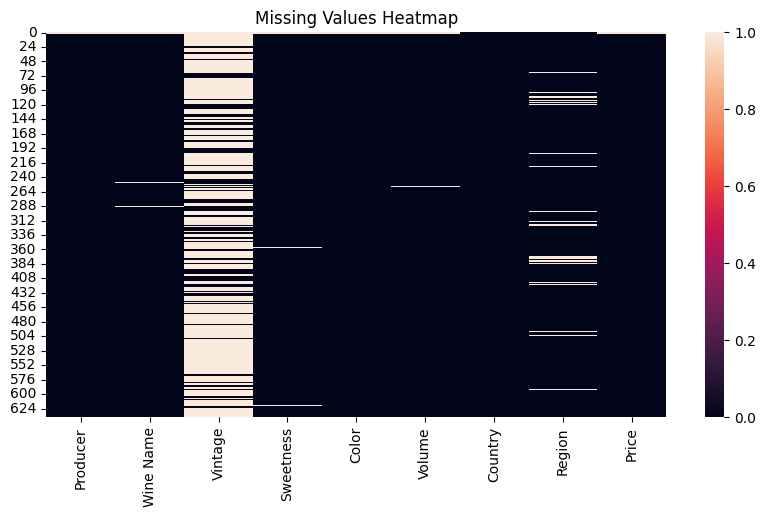

In [ ]:
# Check missing values with heatmap
cols = df.columns

plt.figure(figsize = (10,5))
sns.heatmap(df[cols].isnull())
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
# Check missing values percentage
missing_pct = round(df.isnull().sum()/len(df) * 100, 1)
print(missing_pct)

Producer      0.5
Wine Name     1.1
Vintage      73.6
Sweetness     0.8
Color         0.5
Volume        0.6
Country       0.0
Region        5.9
Price         0.5
dtype: float64


In [ ]:
# Drop 'Vintage' column due to high missing values
df = df.drop(columns=['Vintage'])

# Fill missing 'Region' based on most frequent value per 'Country'
df['Region'] = df.groupby('Country')['Region'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

# Fill missing 'Sweetness' with mode
df['Sweetness'] = df['Sweetness'].fillna(df['Sweetness'].mode()[0])

# Drop rows where 'Wine Name' is missing
df = df.dropna(subset=['Wine Name'])

# Fill missing 'Volume' with mode
df['Volume'] = df['Volume'].fillna(df['Volume'].mode()[0])

In [ ]:
df.duplicated().sum()#there are 7 duplicate rows in the DataFrame

np.int64(7)

In [ ]:
#Dataframe before removing the duplicates
print(f"Original DataFrame shape: {df.shape}")

df = df.drop_duplicates()
#After
print(f"DataFrame shape after removing duplicates: {df.shape}")
display(df.head())

Original DataFrame shape: (632, 8)
DataFrame shape after removing duplicates: (625, 8)


,Producer,Wine Name,Sweetness,Color,Volume,Country,Region,Price
3,DOMAINE CHATELAIN,"""Les Charmes"" Pouilly Fumé",dry,white wine,0.75,France,Loire Valley,9 900
4,HORIZON De Bichot,Pinot Noir,dry,red wine,0.75,France,Limoux,7 800
5,HORIZON De Bichot,Chardonnay,dry,white wine,0.75,France,Limoux,7 800
6,ALBERT BICHOT,"""Meursault""",dry,white wine,0.75,France,Burgundy,55 000
7,ALBERT BICHOT,Puligny-Montrachet 1er Cru Les Garennes,dry,white wine,0.75,France,Burgundy,120 000


In [ ]:
# Save the cleaned DataFrame to a CSV file in Google Drive
df.to_csv('/content/drive/MyDrive/wine_data_cleaned.csv', index=False)

print("Cleaned wine data saved to wine_data_cleaned.csv in Google Drive")

Cleaned wine data saved to wine_data_cleaned.csv in Google Drive


## Cleaned data link
[Cleaned CSV file ](https://drive.google.com/file/d/17ZOtkMQCc0RqytNiBthT8lLhWN2-exeN/view?usp=sharing)

##3.Data Preprocessing


In [ ]:
import pandas as pd

# Extract numeric values from the 'Volume' column (e.g., "0.75 l") and convert them to float
df['Volume'] = df['Volume'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Remove spaces from 'Price' and turn it into a number
df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace(' ', '', regex=False), errors='coerce').astype('Int64')

### 3.1.Feature Engineering

In this step, new features were created from existing data to enhance the analytical potential of the dataset:  

- **Price per Liter (`Price_per_Liter`)**: Calculated by dividing the wine’s price by its volume, providing a standardized measure to compare wines of different bottle sizes.  
- **Price Category (`Price_Category`)**: Wines were classified into three categories — *Budget*, *Mid*, and *Luxury* — based on their price ranges. This categorical feature simplifies comparisons and enables grouping analyses for price segments.  

These engineered features help in understanding relative pricing and allow for more meaningful visualizations and statistical analysis.


In [ ]:
# Create a new feature: Price per litre
df['Price_per_Liter'] = df['Price'] / df['Volume']

In [ ]:
# Create a new column 'Price_Category' to label wines as Budget, Mid, or Luxury based on their price
df['Price_Category'] = pd.cut(df['Price'], bins=[0, 10000, 50000, float('inf')], labels=['Budget', 'Mid', 'Luxury'])

print("Number of wines in each price category:")
display(df['Price_Category'].value_counts())

print("\nDataFrame with new 'Price_Category' column (first 10 rows):")
display(df.head(10))

Number of wines in each price category:


,count
Price_Category,
Budget,308
Mid,214
Luxury,103



DataFrame with new 'Price_Category' column (first 10 rows):


,Producer,Wine Name,Sweetness,Color,Volume,Country,Region,Price,Price_per_Liter,Price_Category
3,DOMAINE CHATELAIN,"""Les Charmes"" Pouilly Fumé",dry,white wine,0.75,France,Loire Valley,9900,13200.0,Budget
4,HORIZON De Bichot,Pinot Noir,dry,red wine,0.75,France,Limoux,7800,10400.0,Budget
5,HORIZON De Bichot,Chardonnay,dry,white wine,0.75,France,Limoux,7800,10400.0,Budget
6,ALBERT BICHOT,"""Meursault""",dry,white wine,0.75,France,Burgundy,55000,73333.333333,Luxury
7,ALBERT BICHOT,Puligny-Montrachet 1er Cru Les Garennes,dry,white wine,0.75,France,Burgundy,120000,160000.0,Luxury
8,ALBERT BICHOT,Chassagne-Montrachet,dry,white wine,0.75,France,Burgundy,60000,80000.0,Luxury
9,ALBERT BICHOT,Puligny-Montrachet,dry,white wine,0.75,France,Burgundy,68000,90666.666667,Luxury
10,ALBERT BICHOT,Saint-Romain,dry,white wine,0.75,France,Burgundy,32000,42666.666667,Mid
11,ALBERT BICHOT,Macon-Villages,dry,white wine,0.75,France,Burgundy,9000,12000.0,Budget
12,ALBERT BICHOT,Bourgogne Aligote,dry,white wine,0.75,France,Burgundy,9000,12000.0,Budget


### 3.2.Data Encoding

To prepare the dataset for analysis, all categorical columns (like Color, Sweetness, Country, Region, and Price Category) were converted into numerical format using one-hot encoding.

Each category becomes a new column.

Rows get a `1(True)` in the column corresponding to their category and `0(False)` in all others.

This allows models to use categorical data without assuming any order between categories.

In [ ]:
# Select categorical columns to encode
categorical_cols = ['Country', 'Region', 'Color', 'Sweetness', 'Price_Category']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Show the first few rows
display(df_encoded.head())

,Producer,Wine Name,Volume,Price,Price_per_Liter,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Bulgaria,...,Color_rosé wine,Color_white wine,Sweetness_dry,Sweetness_fortified,Sweetness_semi-dry,Sweetness_semi-sweet,Sweetness_sweet,Price_Category_Budget,Price_Category_Mid,Price_Category_Luxury
3,DOMAINE CHATELAIN,"""Les Charmes"" Pouilly Fumé",0.75,9900,13200.0,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
4,HORIZON De Bichot,Pinot Noir,0.75,7800,10400.0,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
5,HORIZON De Bichot,Chardonnay,0.75,7800,10400.0,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
6,ALBERT BICHOT,"""Meursault""",0.75,55000,73333.333333,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True
7,ALBERT BICHOT,Puligny-Montrachet 1er Cru Les Garennes,0.75,120000,160000.0,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True


### 3.3.Data Transformation: Normalizing Numeric Columns

We scale numeric columns to make them easier to compare and analyze.

Here, we change numeric columns like Price and Volume so that their values are between 0 and 1.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select numeric columns to normalize
numeric_cols = ['Price', 'Volume', 'Price_per_Liter']

# Apply Min-Max scaling (values between 0 and 1)
scaler = MinMaxScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Check min/max values to verify
print(df_encoded[numeric_cols].describe())
df_encoded.head()

            Price      Volume  Price_per_Liter
count  625.000000  625.000000       625.000000
mean     0.027726    0.213971         0.039823
std      0.078825    0.087956         0.100466
min      0.000000    0.000000         0.000000
25%      0.002355    0.200142         0.003712
50%      0.005064    0.200142         0.008527
75%      0.015781    0.200142         0.023074
max      1.000000    1.000000         1.000000


,Producer,Wine Name,Volume,Price,Price_per_Liter,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Bulgaria,...,Color_rosé wine,Color_white wine,Sweetness_dry,Sweetness_fortified,Sweetness_semi-dry,Sweetness_semi-sweet,Sweetness_sweet,Price_Category_Budget,Price_Category_Mid,Price_Category_Luxury
3,DOMAINE CHATELAIN,"""Les Charmes"" Pouilly Fumé",0.200142,0.004770,0.007725,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
4,HORIZON De Bichot,Pinot Noir,0.200142,0.003533,0.005618,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
5,HORIZON De Bichot,Chardonnay,0.200142,0.003533,0.005618,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
6,ALBERT BICHOT,"""Meursault""",0.200142,0.031327,0.052970,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True
7,ALBERT BICHOT,Puligny-Montrachet 1er Cru Les Garennes,0.200142,0.069603,0.118178,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True


## 4.Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand the characteristics of wine products, their distributions, and relationships between features. This helps identify patterns, trends, and potential issues before modeling.

### 4.1.Descriptive Statistics

We look at basic numbers for the dataset, like the average (mean), middle value (median), and spread (standard deviation). This helps us understand the typical values and how much they vary. For example, we check columns like `Price` and `Volume` to see the usual wine prices and sizes.




- **Price**: Most wines are cheap. The average price (0.028) is higher than the middle value (0.005) because a few expensive wines increase the average. This means the prices are not evenly spread.  
- **Volume** : Most wine bottles have similar sizes. There is not much difference between them.  
- **Price per Liter**: Prices per liter vary a lot (from 2,933 to 1,332,000 AMD). Most wines are in the lower to middle price range, but some are very expensive.  






In [ ]:
df[['Price', 'Volume', 'Price_per_Liter']].describe()

#Price: Wines vary a lot in price, from 1,800 AMD to 1,700,000 AMD. Most wines are affordable, but a few very expensive ones increase the average (48,884 AMD) compared to the median (10,400 AMD), showing skewed pricing.

#Volume: Most bottles are around 0.75 L, with some smaller (0.187 L) and larger bottles (3 L). Variation is low (std ≈ 0.25).

#Price per Liter: Wide range from 2,933 AMD to 1,332,000 AMD. Most wines are moderately priced per liter, but some luxury wines make the mean (55,861 AMD) much higher than the median (14,267 AMD).


,Price,Volume,Price_per_Liter
count,625.0,625.000000,625.0
mean,48883.76,0.788899,55861.16107
std,133860.57697,0.247421,133526.416858
min,1800.0,0.187000,2933.333333
25%,5800.0,0.750000,7866.666667
50%,10400.0,0.750000,14266.666667
75%,28600.0,0.750000,33600.0
max,1700000.0,3.000000,1332000.0


###4.2. Distribution Analysis

- We looked at how the main numbers (`Price`, `Volume`, `Price_per_Liter`) are spread using histograms and KDE plots.
- Checked if the data is balanced, or if it has a lot of small or very big values (skewed or has outliers).
- Looked at skewness and kurtosis to see the shape and peak of the data.
- This helps us understand the data better before doing any modeling.


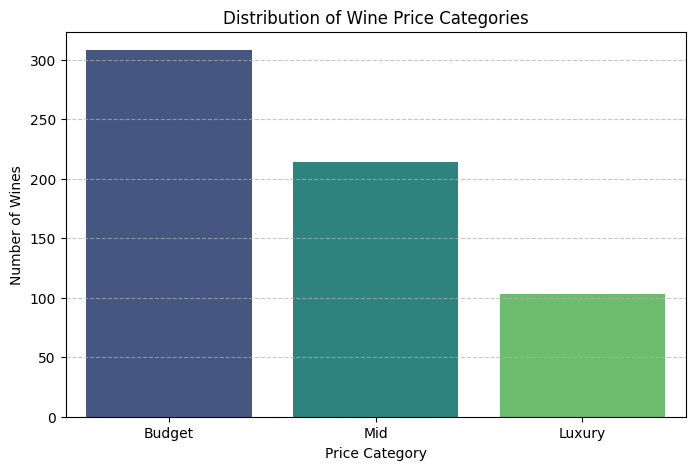

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Scatter plot of wine prices
plt.figure(figsize=(8, 5))
sns.countplot(x='Price_Category', data=df, hue='Price_Category', legend=False, order=['Budget', 'Mid', 'Luxury'], palette='viridis')
plt.title('Distribution of Wine Price Categories')
plt.xlabel('Price Category')
plt.ylabel('Number of Wines')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#The plot shows that the majority of wines fall into the Budget category, with fewer wines in the Mid category and even fewer in the Luxury category.
#This indicates that most wines in the dataset are affordable, while high-end wines are relatively rare.

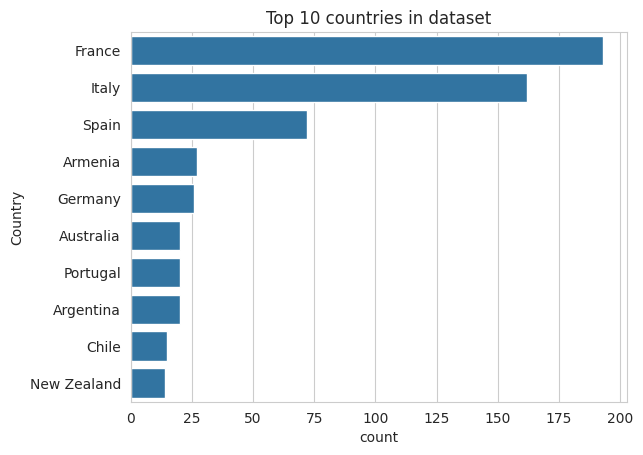

In [ ]:
# Distribution of wines by country

df['Country'].value_counts() # Count wines per country
sns.set_style('whitegrid')

plt.figure()
sns.countplot(y='Country', data=df, order=df['Country'].value_counts().index[:10])
plt.title('Top 10 countries in dataset')
plt.show()



#The plot highlights the top 10 countries with the most wines in the dataset.
#Countries like Italy, France, and Spain dominate, indicating that these nations are the most represented in the collection.
#This suggests a strong European presence in the dataset, while other regions contribute fewer wines.

In [ ]:
# Average price by country
df.groupby('Country')['Price'].mean().sort_values(ascending=False)



#The average price of wines varies significantly by country.
#China and the USA have the highest average prices, indicating a focus on premium wines, while countries like Bulgaria, South Africa, and Austria have much lower average prices, suggesting more budget-friendly options.
#European countries such as Italy and France fall in the mid to high range, reflecting both premium and mid-range wines in the dataset.

#This shows that wine pricing is highly dependent on the country of origin.

,Price
Country,
China,169000.0
USA,97790.909091
Italy,81002.469136
France,66344.041451
Chile,20040.0
Spain,18118.055556
Lebanon,11971.428571
Australia,11740.0
Armenia,11224.074074


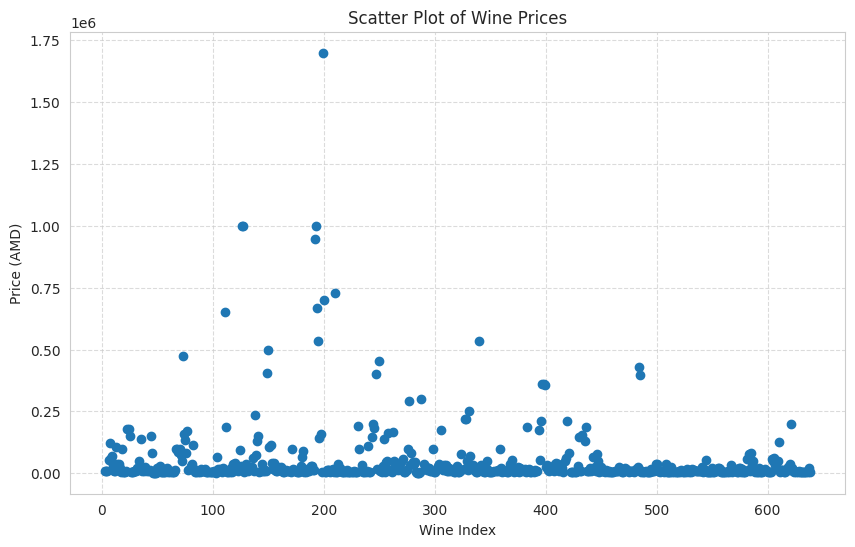

In [ ]:
# Scatter plot of wine prices
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['Price'])
plt.title('Scatter Plot of Wine Prices')
plt.xlabel('Wine Index')
plt.ylabel('Price (AMD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



#The scatter plot shows that most wines in the dataset are priced at the lower end, while only a few wines are extremely expensive.
#The prices do not follow any clear pattern across the index — instead, they are spread out in a random way.

#This means wine prices vary a lot, but high-priced wines are rare compared to the many affordable ones.

In [ ]:
df['Volume'].value_counts()# Distribution of Volume

#Most wines come in the standard 0.75 L bottle size (575 out of 625). Larger or smaller bottle sizes are very rare.

#The dataset is dominated by regular 750 ml bottles, meaning shops mainly sell standard-size wines.

,count
Volume,
0.750,575
1.500,29
0.375,9
3.000,4
0.500,4
0.250,3
0.187,1


In [ ]:
# Distribution of Color
df['Color'].value_counts()



#The majority of wines are red (372), followed by white (215). Rosé wines are uncommon (38).

#Red wines are the most widely available, while rosé is a small niche in the store’s selection.

,count
Color,
red wine,372
white wine,215
rosé wine,38


In [ ]:
# Distribution of Sweetness
df['Sweetness'].value_counts()


#Most wines are dry (589). Sweet, semi-sweet, fortified, and semi-dry wines appear only a few times.

#Dry wines make up almost the entire market in this shop. Other sweetness types are rare and limited in variety.

,count
Sweetness,
dry,589
sweet,12
semi-sweet,9
fortified,8
semi-dry,7


In [ ]:
# Top 10 most expensive wines
df.nlargest(10, 'Price')




#All wines are dry red wines, showing that luxury wines in this market are heavily concentrated in this category.
#The top producers include world-famous estates such as Château Angélus, Masseto, Tenuta San Guido (Sassicaia), and Château Lafite Rothschild.
#Most of these wines come from France and Italy, confirming that these two countries dominate the premium wine segment.
#Luxury wines often come in larger bottle sizes (1.5 L or 3 L), which increases both their price and their price per liter.

,Producer,Wine Name,Sweetness,Color,Volume,Country,Region,Price,Price_per_Liter,Price_Category
199,CHATEAU ANGELUS,"""Hommage Elisabeth Bouchet"" MAGNUM",dry,red wine,1.50,France,Bordeaux,1700000,1133333.333333,Luxury
126,MASSETO,Toscana,dry,red wine,0.75,Italy,Tuscany,999000,1332000.0,Luxury
127,VERITE,"""La Joie, La Muse, Le Desir"" 3x0.75",dry,red wine,0.75,USA,California,999000,1332000.0,Luxury
193,TENUTA SAN GUIDO,SASSICAIA 3 L,dry,red wine,3.00,Italy,Tuscany,999000,333000.0,Luxury
192,TENUTA SAN GUIDO,SASSICAIA 3 L,dry,red wine,3.00,Italy,Tuscany,945000,315000.0,Luxury
210,TENUTA SAN GUIDO,SASSICAIA Magnum,dry,red wine,1.50,Italy,Tuscany,727000,484666.666667,Luxury
200,CHATEAU ANGELUS,"""Hommage Elisabeth Bouchet""",dry,red wine,0.75,France,Bordeaux,700000,933333.333333,Luxury
194,TENUTA SAN GUIDO,SASSICAIA Magnum,dry,red wine,1.50,Italy,Tuscany,667000,444666.666667,Luxury
111,CHATEAU LAFITE ROTHSCHILD,Pauillac AOC,dry,red wine,0.75,France,Bordeaux,650000,866666.666667,Luxury
340,TENUTA SAN GUIDO,SASSICAIA Magnum,dry,red wine,1.50,Italy,Tuscany,535000,356666.666667,Luxury


In [ ]:
# Cheapest wine by country (first 10)
display(df.loc[df.groupby('Country')['Price'].idxmin()].sort_values(by='Price').head(10))




#Most wines in the dataset are red, dry, and have a standard bottle size of 0.75 liters.
#The majority of wines are affordable (Budget category), but there are a few extremely expensive wines in the Luxury category.
#The dataset covers a variety of countries, with France, Italy, and the USA producing some of the highest-priced wines.

#Overall, the data shows that while most wines are common and reasonably priced, there are exceptional premium wines that significantly increase the average prices.
#This mix gives a good overview of the wine market in terms of price, type, and origin.

,Producer,Wine Name,Sweetness,Color,Volume,Country,Region,Price,Price_per_Liter,Price_Category
46,JACOB'S CREEK,Classic Shiraz Cabernet 0.187,dry,red wine,0.187,Australia,South Eastern Australia,1800,9625.668449,Budget
47,HANS BAER,Pinot Noir 0.25 L,dry,red wine,0.250,Germany,Pfalz,1800,7200.0,Budget
284,VERCOOPE,"""Pavao"" Escolha",dry,white wine,0.750,Portugal,Vinho Verde,2500,3333.333333,Budget
593,BODEGAS VICTORIANAS,"""Monterio"" Rosé",dry,rosé wine,0.750,Spain,Castilla - La Mancha,2800,3733.333333,Budget
60,FANTINI,CALDORA Ortonese Malvasia-Chardonnay,dry,white wine,0.750,Italy,Puglia,3200,4266.666667,Budget
20,TRINITY,Crossroads Red,dry,red wine,0.750,Armenia,Vayots Dzor,3300,4400.0,Budget
524,OMBRE ROSÉ,Collines de la Moure,dry,rosé wine,0.750,France,Languedoc-Roussillon,3400,4533.333333,Budget
64,ROBERTSON WINERY,"""Chapel"" White",dry,white wine,0.750,South Africa,Robertson,3600,4800.0,Budget
223,ROUGH DAY,"""Cabernet Sauvignon""",dry,red wine,0.750,Bulgaria,Thracian Valley,3600,4800.0,Budget
84,BODEGA DEL FIN DEL MUNDO,Postales Malbec,dry,red wine,0.750,Argentina,Patagonia,3800,5066.666667,Budget


In [ ]:
# Price statistics by region
df.groupby('Region')['Price'].agg(['min', 'max', 'mean'])





#Wine prices vary greatly depending on the region of production. Some regions, like Yunnan and Aconcagua, have very high-priced wines, while regions like Vinho Verde and Western Cape mostly produce affordable wines.
#On average, most regions have mid-range prices, showing that the wine market includes both common and premium options depending on the region.

,min,max,mean
Region,,,
Abruzzo,3600,20600,8438.461538
Aconcagua,28000,90000,61666.666667
Alicante,5800,8600,7200.0
Almansa,15000,15000,15000.0
Alsace,5000,28600,12091.666667
...,...,...,...
Veneto,4400,185000,40417.647059
Vinho Verde,2500,3500,2833.333333
Wachau,4500,16800,8671.428571


In [ ]:
# Average price by wine color
df.groupby('Color')['Price'].mean()


#Red wines are the most expensive on average, followed by white wines, while rosé wines tend to be the cheapest.

#This shows that wine color is related to price, with red wines often being premium products.

,Price
Color,
red wine,72276.612903
rosé wine,8851.315789
white wine,15484.186047


In [ ]:
# Top 20 producers by average price
df.groupby('Producer')['Price'].mean().sort_values(ascending=False).head(20)




#The analysis shows that a few producers consistently sell high-priced wines, while most producers offer more affordable options.
#The top producers, such as VERITE, MASSETO, and CHATEAU LAFITE ROTHSCHILD, have much higher average prices compared to the rest.

#This indicates a clear price gap between luxury and budget wines, highlighting the diversity in the wine market.

,Price
Producer,
VERITE,999000.0
MASSETO,999000.0
CHATEAU LAFITE ROTHSCHILD,650000.0
CHATEAU ANGELUS,400525.0
TENUTA SAN GUIDO,395866.666667
CHÂTEAU HAUT-BRION,395000.0
CHATEAU MARGAUX,329333.333333
CHÂTEAU LATOUR,308500.0
CHATEAU ANGELUS,290000.0


In [ ]:
#Country & Color vs expensive wines
pd.crosstab([df['Country'], df['Color']], df['Price'] > 50000)




#The table shows the count of wines by country and color, split between luxury wines (True) and non-luxury wines (False).
# Most countries and colors mostly produce non-luxury wines. Luxury wines are rare and mostly come from countries like France, Italy, Chile, China, Spain, and the USA, often in red or white varieties.
#This highlights that only a few producers and regions dominate the high-end wine market, while most wines are more affordable.

Price                    False  True 
Country      Color                   
Argentina    red wine       14      0
             white wine      6      0
Armenia      red wine       17      0
             rosé wine       2      0
             white wine      8      0
Australia    red wine       13      0
             white wine      7      0
Austria      red wine        1      0
             white wine     13      0
Bulgaria     red wine        3      0
Chile        red wine        8      2
             white wine      5      0
China        red wine        0      1
France       red wine       63     39
             rosé wine      14      1
             white wine     64     12
Germany      red wine        2      0
             rosé wine       3      0
             white wine     21      0
Hungary      red wine        1      0
             white wine      7      0
Israel       red wine        1      0
             rosé wine       1      0
Italy        red wine       81     42
             rosé wine       7      0
             white wine     31      1
Lebanon      red wine        3      0
             rosé wine       2      0
             white wine      2      0
New Zealand  red wine        6      0
             rosé wine       2      0
             white wine      6      0
Portugal     red wine       10      1
             rosé wine       2      0
             white wine      7      0
South Africa red wine        6      0
             white wine      4      0
Spain        red wine       47      3
             rosé wine       3      0
             white wine     19      0
USA          red wine        7      1
             rosé wine       1      0
             white wine      2      0

In [ ]:
# Wines with price greater than 500,000
df[df['Price'] > 500000]



#This table shows the most expensive wines in the dataset, all classified as luxury.
#Most are red wines from France and Italy, with a few from the USA. The prices per liter are very high, showing that these wines are premium products.
# Bottles vary in volume, from standard 0.75 L to larger 1.5–3 L bottles, but all represent high-end wines targeted at a luxury market.

,Producer,Wine Name,Sweetness,Color,Volume,Country,Region,Price,Price_per_Liter,Price_Category
111,CHATEAU LAFITE ROTHSCHILD,Pauillac AOC,dry,red wine,0.75,France,Bordeaux,650000,866666.666667,Luxury
126,MASSETO,Toscana,dry,red wine,0.75,Italy,Tuscany,999000,1332000.0,Luxury
127,VERITE,"""La Joie, La Muse, Le Desir"" 3x0.75",dry,red wine,0.75,USA,California,999000,1332000.0,Luxury
192,TENUTA SAN GUIDO,SASSICAIA 3 L,dry,red wine,3.00,Italy,Tuscany,945000,315000.0,Luxury
193,TENUTA SAN GUIDO,SASSICAIA 3 L,dry,red wine,3.00,Italy,Tuscany,999000,333000.0,Luxury
194,TENUTA SAN GUIDO,SASSICAIA Magnum,dry,red wine,1.50,Italy,Tuscany,667000,444666.666667,Luxury
195,TENUTA SAN GUIDO,SASSICAIA Magnum,dry,red wine,1.50,Italy,Tuscany,533000,355333.333333,Luxury
199,CHATEAU ANGELUS,"""Hommage Elisabeth Bouchet"" MAGNUM",dry,red wine,1.50,France,Bordeaux,1700000,1133333.333333,Luxury
200,CHATEAU ANGELUS,"""Hommage Elisabeth Bouchet""",dry,red wine,0.75,France,Bordeaux,700000,933333.333333,Luxury
210,TENUTA SAN GUIDO,SASSICAIA Magnum,dry,red wine,1.50,Italy,Tuscany,727000,484666.666667,Luxury


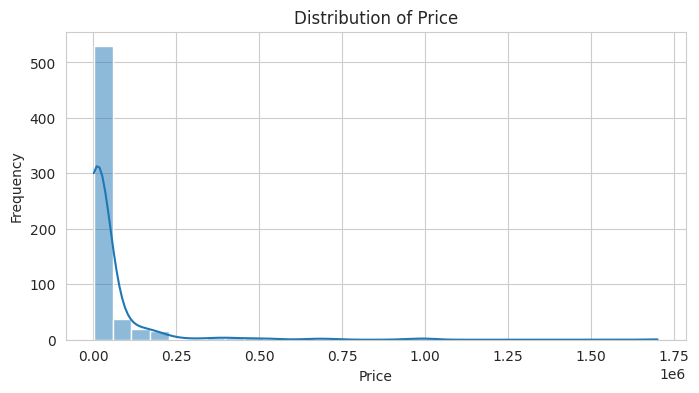

Skewness of Price: 6.457826910525798
Kurtosis of Price: 54.57615967781597


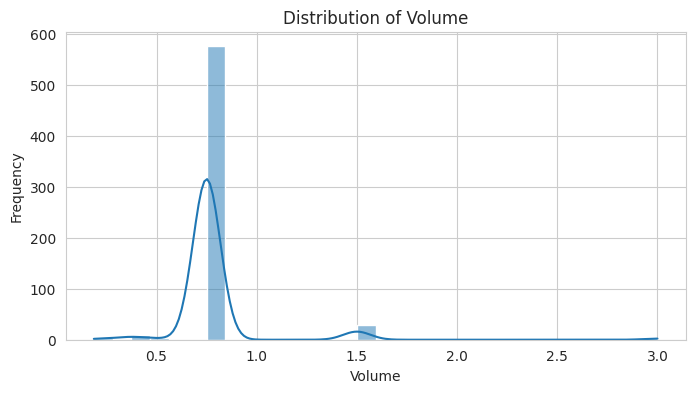

Skewness of Volume: 5.528710314425909
Kurtosis of Volume: 41.41701833109824


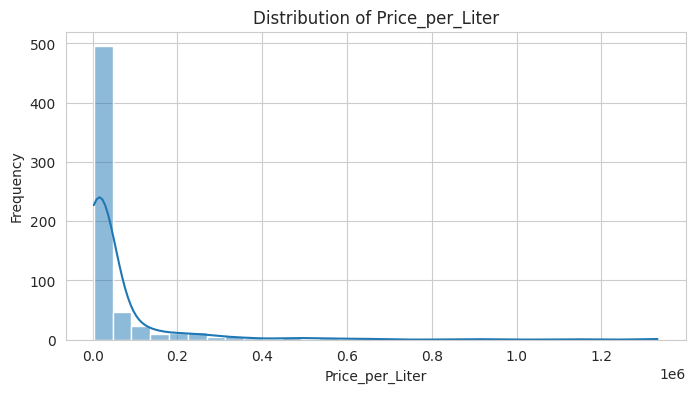

Skewness of Price_per_Liter: 5.577916459919512
Kurtosis of Price_per_Liter: 39.66229489464705


In [ ]:
numeric_features = ['Price', 'Volume', 'Price_per_Liter']

for feature in numeric_features:
    # Histogram with KDE
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

    # Calculating skewness and kurtosis on the unscaled data (df)
    feature_skewness = skew(df[feature].dropna())
    feature_kurtosis = kurtosis(df[feature].dropna())
    print(f"Skewness of {feature}:", feature_skewness)
    print(f"Kurtosis of {feature}:", feature_kurtosis)





#We looked at how the numeric features—Price, Volume, and Price per Liter—are distributed.
#Most wines are low-priced and small to medium in volume, while a few very expensive wines make the price distribution skewed to the right.
#The skewness shows that prices are not evenly spread, and the kurtosis indicates that there are extreme values in the dataset.

#This helps us understand that most wines are affordable, with some very high-end outliers.


### 4.3.Correlation Analysis

We analyzed how the numerical features relate to each other using a correlation matrix.






                    Price    Volume  Price_per_Liter
Price            1.000000  0.387335         0.908986
Volume           0.387335  1.000000         0.145976
Price_per_Liter  0.908986  0.145976         1.000000


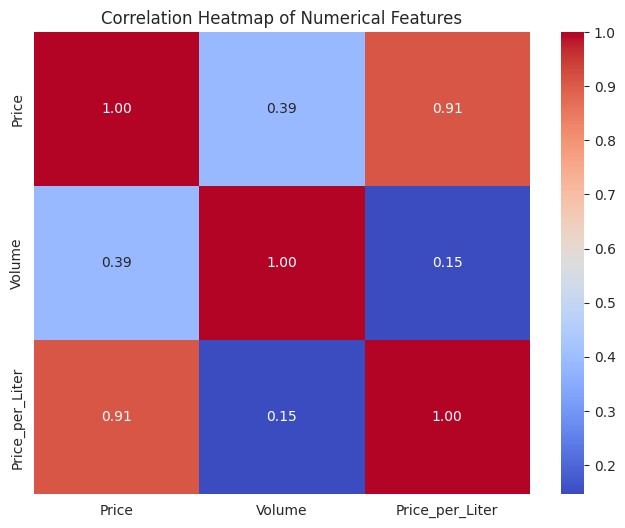

In [ ]:

# Select numerical features for correlation
numeric_features = ['Price', 'Volume', 'Price_per_Liter']  # add more if needed

# Compute correlation matrix
corr_matrix = df_encoded[numeric_features].corr()

# Display correlation matrix
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()



#Price and Price_per_Liter (0.91): Strong positive correlation — as the wine price increases, the price per liter also increases.
#Price and Volume (0.39): Moderate positive correlation — more expensive wines tend to have slightly higher volumes.
#Volume and Price_per_Liter (0.15): Very weak correlation — volume and price per liter are almost independent.

### 4.4.Hypothesis Testing: Are Some Producers More Likely to Offer Luxury Wines?

- **Null Hypothesis (H₀):** Every producer has the same probability of offering a luxury wine (> 50 k AMD).  
- **Alternative Hypothesis (H₁):** At least one producer has a different probability.  



In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# 1. Mark wines as luxury or not (> 50,000 AMD)
df['is_luxury'] = df['Price'] > 50000

# 2. Keep producers that appear at least 5 times (to make the test reliable)
valid_producers = df['Producer'].value_counts()
valid_producers = valid_producers[valid_producers >= 5].index

# 3. Create the contingency table: Producer vs Luxury/Not Luxury
cont_table = pd.crosstab(
    df[df['Producer'].isin(valid_producers)]['Producer'],
    df['is_luxury']
)

print("Contingency Table:")
print(cont_table)

# 4. Run the Chi-square test
chi2, p_value, dof, expected = chi2_contingency(cont_table)

print("\nChi-square:", round(chi2, 2))
print("p-value:", p_value)
print("Degrees of Freedom:", dof)

# 5. Conclusion
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject H0.")
    print("Different producers DO NOT have the same chance of producing luxury wines.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("Producers seem to have the SAME chance of producing luxury wines.")



#Results:

#Chi-squared Statistic: 230.90
#P-value: 2.653e-28

#Interpretation:
#Since the p-value (2.653e-28) is significantly less than 0.05, we reject the null hypothesis.
#This indicates that there is a significant difference in the probability of offering a luxury wine among different producers.
#In other words, some producers are indeed more likely to offer luxury wines than others.


Contingency Table:
is_luxury                 False  True 
Producer                              
ALBERT BICHOT                12      8
ASTORIA                       6      0
ATTIS BODEGA & VINEDOS        8      0
BIBI GRAETZ                   1      5
BODEGA DEL FIN DEL MUNDO     13      0
BODEGAS FAUSTINO              5      0
BODEGAS RODA                 10      2
CAMPO VIEJO                   7      0
CASA ROJO                    13      0
CHATEAU ANGELUS               2      6
CHOCALAN                      6      0
CHÂTEAU MIRAVAL               7      1
DE MARTINO                    6      0
DOMAINE CLARENCE DILLON       5      1
DOMAINE FAIVELEY              5      0
DOMAINE JACQUES PRIEUR        4      1
DOMAINE SERVIN                5      0
DOMANE WACHAU                 7      0
DULONG                        7      0
FANTINI                      19      0
FONTANAFREDDA                12      0
GAJA                          9      9
HANS BAER                     5      0
HOSPIC

##5.Data Visualization

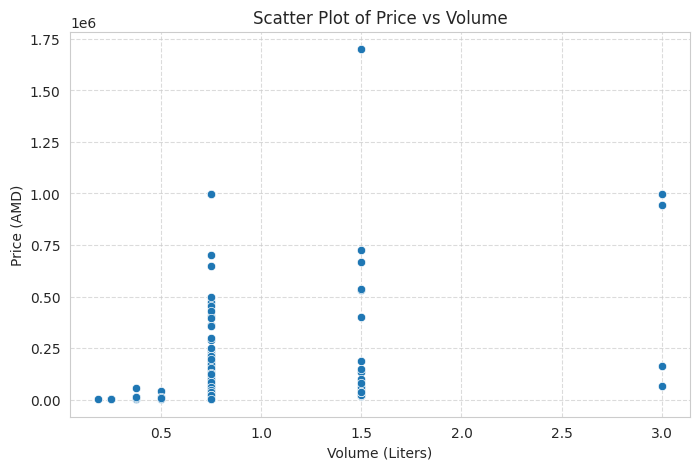

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: Price vs Volume
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Volume', y='Price', data=df)
plt.title('Scatter Plot of Price vs Volume')
plt.xlabel('Volume (Liters)')
plt.ylabel('Price (AMD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



#This scatter plot shows the relationship between wine volume and price.

#Most wines are around 0.75 L with lower prices.

#Some large or premium bottles (1.5–3 L) have much higher prices.

#There isn’t a strict linear relationship, but bigger bottles tend to cost more, especially among luxury wines.



/tmp/ipython-input-4170502747.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Color', y='Price', data=df, jitter=True, palette='Set2')


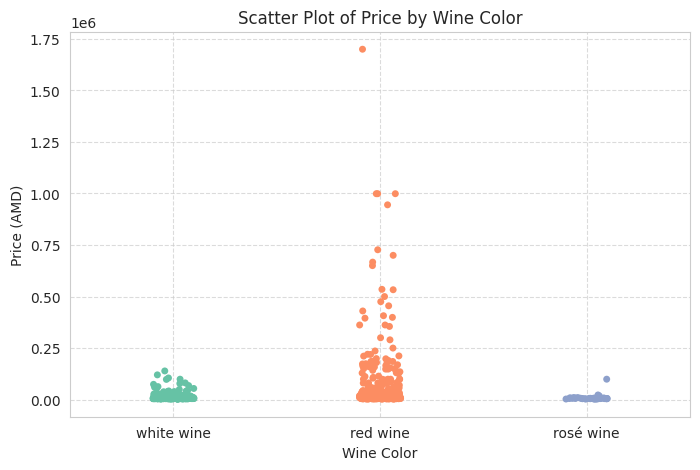

In [ ]:
plt.figure(figsize=(8,5))
sns.stripplot(x='Color', y='Price', data=df, jitter=True, palette='Set2')
plt.title('Scatter Plot of Price by Wine Color')
plt.xlabel('Wine Color')
plt.ylabel('Price (AMD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


#In the scatter plot of Price by Wine Color, red wines show a wide range of prices, from low to very high.
#White wines are mostly in the low to mid price range. Rosé wines have very low prices compared to red and white wines.
#This plot helps us see how prices are different depending on the wine color.


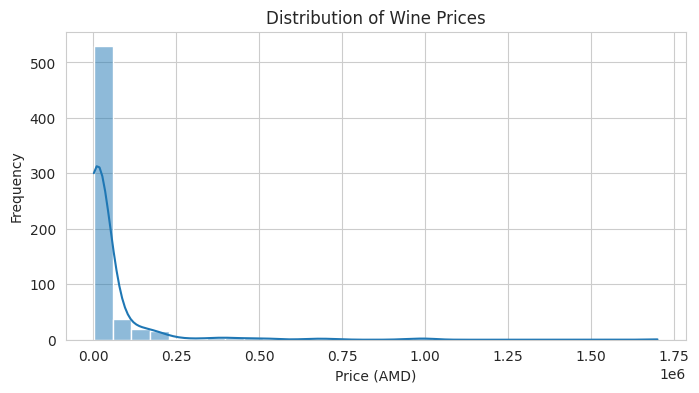

In [ ]:
# Histogram of Price
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Distribution of Wine Prices')
plt.xlabel('Price (AMD)')
plt.ylabel('Frequency')
plt.show()

#Most wines are cheap


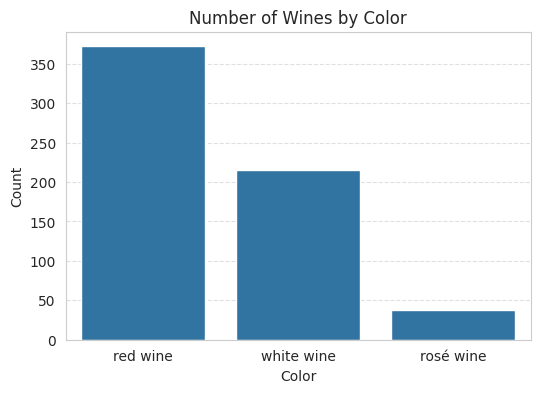

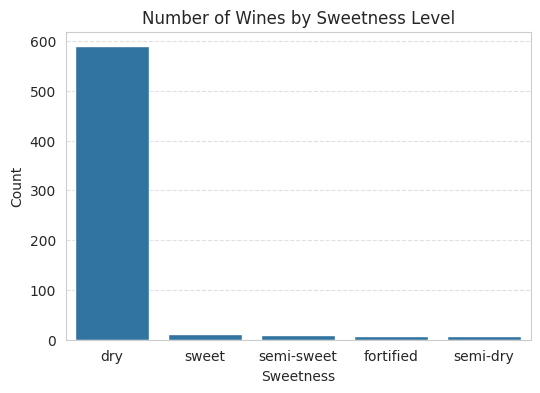

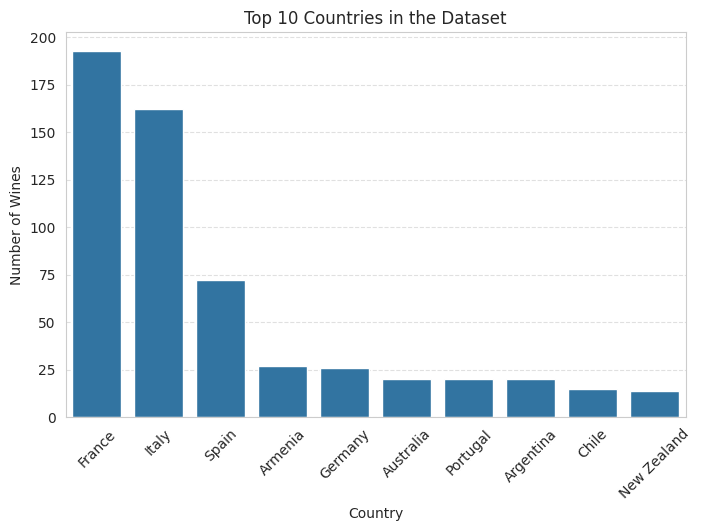

In [ ]:

# Bar plot: Wine counts by Color

plt.figure(figsize=(6, 4))
sns.countplot(x='Color', data=df, order=df['Color'].value_counts().index)
plt.title('Number of Wines by Color')
plt.xlabel('Color')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


# Bar plot: Wine counts by Sweetness

plt.figure(figsize=(6, 4))
sns.countplot(x='Sweetness', data=df, order=df['Sweetness'].value_counts().index)
plt.title('Number of Wines by Sweetness Level')
plt.xlabel('Sweetness')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


# Bar plot: Top 10 most common Countries

plt.figure(figsize=(8, 5))
sns.countplot(
    x='Country',
    data=df,
    order=df['Country'].value_counts().index[:10]
)
plt.title('Top 10 Countries in the Dataset')
plt.xlabel('Country')
plt.ylabel('Number of Wines')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


##**Conclusion**


From this research, we learned that most wines in the dataset are affordable, dry, and red, with standard bottle sizes, while a few luxury wines significantly increase the average price. We observed that certain countries, such as France, Italy, and the USA, as well as specific producers like TENUTA SAN GUIDO and CHATEAU ANGELUS, are more likely to offer luxury wines. The analysis of price per liter revealed large differences in value, highlighting the variability in the market. Overall, the study provided a clear understanding of wine characteristics, pricing patterns, and the differences between producers and regions, giving insights into the structure and trends of the wine market.